In [4]:
import tensorflow as tf
from numpy import loadtxt
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers
from tensorflow.python.keras.optimizers import *
import numpy as np


#Load dataset
#split into input (X) and output (y)
X = np.array([
    [1.0], [128.0], [2187.0], [16384.0], [78125.0], [279936.0], [823543.0], [2097152.0], [4782969.0], [10000000.0],
    [19487171.0], [35831808.0], [62748517.0], [105413504.0], [170859375.0], [268435456.0], [410338673.0], [612220032.0], [893871739.0], [1280000000.0]
])
y = np.array([
    [1.0], [2.0], [3.0], [4.0], [5.0], [6.0], [7.0], [8.0], [9.0], [10.0],
    [11.0], [12.0], [13.0], [14.0], [15.0], [16.0], [17.0], [18.0], [19.0], [20.0]
])

#define keras model
model = Sequential()

model.add(Dense(6,input_dim=1,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(1))

#compile the keras model
opt = optimizers.Adam(learning_rate=0.001)
mse = tf.keras.losses.MeanSquaredError(
    reduction=tf.keras.losses.Reduction.SUM)
model.compile(loss=mse, optimizer=opt)



#fit the keras model on the dataset (CPU)
model.fit(X,y,epochs=2000,batch_size=10, verbose=0)
model.summary()

#make class predictions with the model
predictions = model.predict(X)

#summarize the first 10 cases
for i in range(len(X)):
    print('%s => %.2f (expected %.2f)' %(X[i].tolist(), predictions[i], y[i]) )

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 6)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 311 (1.22 KB)

 Trainable params: 103 (412.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 208 (836.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
[1.0] => -0.09 (expected 1.00)
[128.0] => -0.09 (expected 2.00)
[2187.0] => -0.09 (expected 3.00)
[16384.0] => -0.09 (expected 4.00)
[78125.0] => -0.09 (expected 5.00)
[279936.0] => -0.10 (expected 6.00)
[823543.0] => -0.12 (expected 7.00)
[2097152.0] => -0.13 (expected 8.00)
[4782969.0] => -0.03 (expected 9.00)
[10000000.0] => 0.21 (expected 10.00)
[19487171.0] => 0.30 (expected 11.00)
[35831808.0] => 0.93 (expected 12.00)
[62748517.0] => 2.77 (expected 13.00)
[105413504.0] => 3.48 (expected 14.00)
[170859375.0] => 5.13 (expected 15.00)
[268435456.0] => 8.58 (expected 16.00)
[410338673.0] => 18.32 (expected 17.00)
[612220032.0] => 22.41 (expected 18.00)
[893871739.0] => 36.85 (expected 19.00)
[1280000000.0] => 58.84 (expected 20.00)


/tmp/ipykernel_2360/2763899623.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('%s => %.2f (expected %.2f)' %(X[i].tolist(), predictions[i], y[i]) )


In [5]:
import numpy as np

# Calculate percent error for the new, larger dataset (20 points)
percent_errors_new = np.abs(predictions - y) / y * 100
avg_percent_error_new = np.mean(percent_errors_new)
print(f"New average percent error for 20 data points: {avg_percent_error_new:.2f}%")

New average percent error for 20 data points: 89.97%


In [ ]:
import tensorflow as tf
from numpy import loadtxt
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers
from tensorflow.python.keras.optimizers import *
import numpy as np


#Load dataset
#split into input (X) and output (y)
X = np.array([[1], [128], [2187], [16384], [78125], [279936], [823543], [2097152], [4782969], [10000000]])
X = X*1.0
y = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
y = y*1.0

#define keras model
model = Sequential()

model.add(Dense(6,input_dim=1,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(1))

#compile the keras model
opt = optimizers.Adam(learning_rate=0.001)
mse = tf.keras.losses.MeanSquaredError(
    reduction=tf.keras.losses.Reduction.SUM)
model.compile(loss=mse, optimizer=opt)



#fit the keras model on the dataset (CPU)
model.fit(X,y,epochs=2000,batch_size=10, verbose=0)
model.summary()

#make class predictions with the model
predictions = model.predict(X)

#summarize the first 10 cases
for i in range(10):
    print('%s => %.2f (expected %.2f)' %(X[i].tolist(), predictions[i], y[i]) )

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 311 (1.22 KB)

 Trainable params: 103 (412.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 208 (836.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
[1.0] => 0.24 (expected 1.00)
[128.0] => 0.27 (expected 2.00)
[2187.0] => 0.27 (expected 3.00)
[16384.0] => 0.29 (expected 4.00)
[78125.0] => 0.37 (expected 5.00)
[279936.0] => 0.63 (expected 6.00)
[823543.0] => 1.30 (expected 7.00)
[2097152.0] => 2.97 (expected 8.00)
[4782969.0] => 6.25 (expected 9.00)
[10000000.0] => 13.04 (expected 10.00)


/tmp/ipykernel_2360/1657942701.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('%s => %.2f (expected %.2f)' %(X[i].tolist(), predictions[i], y[i]) )


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


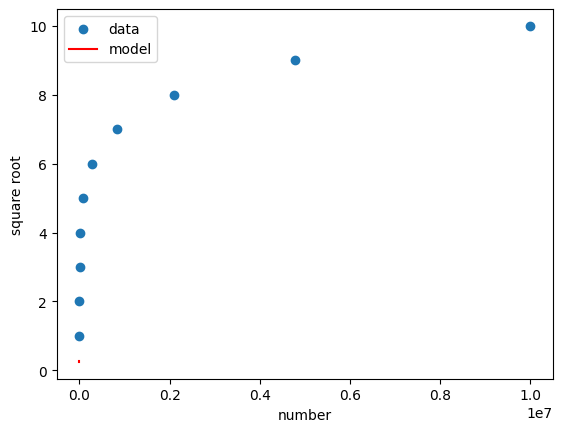

In [2]:
import matplotlib.pyplot as plt
number_grid = np.linspace(1, 100, 100)
plt.scatter(X,y, label='data')
plt.plot(number_grid,model.predict(np.expand_dims(number_grid,axis=1)) , color='red', label='model')
plt.xlabel('number')
plt.ylabel('7th root')
plt.legend()